# Task 1: Predict priority level 1 & level 2 to take preventive measures.
Model: Classification
Input: Incident features (Impact, Urgency, Reassignments, etc.).
Output: Priority level



In [1]:
import sys
!{sys.executable} -m pip install streamlit

  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.1 MB 7.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/10.1 MB 8.7 MB/s eta 0:00:01
   --------------------- ------------------ 5.5/10.1 MB 9.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/10.1 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------  10.0/10.1 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 10.1/10.1 MB 9.8 MB/s  0:00:01
   ---------------------------------------- 0.0/731.2 kB ? eta -:--:--
   ---------------------------------------- 731.2/731.2 kB 7.6 MB/s  0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ------------ --------------------------- 2.1/6.9 MB 10.7 MB/s eta 0:00:01
   --------------------- ------------------ 3.

In [1]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.9/33.9 MB 29.0 MB/s eta 0:00:00


In [2]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.2 MB/s eta 0:00:00


In [3]:
pip install prophet

In [4]:
import mysql.connector
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [5]:
connection = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)
query = "SELECT * FROM dataset_list"

df = pd.read_sql(query, connection)

connection.close()

In [6]:
pd.set_option("display.max_columns",None)

In [7]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [8]:
numeric_columns = [
    "Priority", "number_cnt",
    "No_of_Reassignments", "No_of_Related_Interactions",
    "No_of_Related_Incidents", "No_of_Related_Changes"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "").str.strip(), errors='coerce')

In [9]:
date_columns = ["Open_Time", "Reopen_Time", "Resolved_Time", "Close_Time"]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y %H:%M", errors='coerce')

# Basic Info

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     46606 non-null  object        
 1   CI_Cat                      46606 non-null  object        
 2   CI_Subcat                   46606 non-null  object        
 3   WBS                         46606 non-null  object        
 4   Incident_ID                 46606 non-null  object        
 5   Status                      46606 non-null  object        
 6   Impact                      46606 non-null  object        
 7   Urgency                     46606 non-null  object        
 8   Priority                    45226 non-null  float64       
 9   number_cnt                  46606 non-null  float64       
 10  Category                    46606 non-null  object        
 11  KB_number                   46606 non-null  object    

In [11]:
df.describe()

,Priority,number_cnt,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45226.000000,46606.000000,46605.000000,46606,2284,44826,46606,46492.000000,1222.000000,560.000000
mean,4.215805,0.499658,1.131831,2013-12-24 09:48:58.681714688,2013-12-21 09:21:54.772329216,2013-12-29 15:35:51.013251328,2013-12-29 12:56:57.305497088,1.149897,1.669394,1.058929
min,1.000000,0.000023,0.000000,2012-02-05 13:32:00,2013-04-10 09:15:00,2013-10-01 06:45:00,2013-10-01 06:45:00,1.000000,1.000000,1.000000
25%,4.000000,0.248213,0.000000,2013-11-07 12:29:00,2013-11-05 12:24:00,2013-11-12 16:01:00,2013-11-12 16:43:15,1.000000,1.000000,1.000000
50%,4.000000,0.500269,0.000000,2013-12-23 11:31:00,2013-12-17 10:31:00,2013-12-31 10:33:30,2013-12-31 08:43:00,1.000000,1.000000,1.000000
75%,5.000000,0.749094,2.000000,2014-02-07 15:16:30,2014-02-07 07:55:45,2014-02-12 15:53:45,2014-02-12 14:25:00,1.000000,1.000000,1.000000
max,5.000000,0.999997,46.000000,2014-03-31 17:24:00,2014-03-31 16:21:00,2014-03-31 22:47:00,2014-03-31 22:47:00,370.000000,63.000000,9.000000
std,0.705624,0.288634,2.269774,NaN,NaN,NaN,NaN,2.556338,3.339687,0.403596


In [12]:
df.describe(include='O')

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Category,KB_number,Alert_Status,Handle_Time_hrs,Closure_Code,Related_Interaction,Related_Change
count,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606
unique,3019,13,65,274,46606,2,6,6,4,1825,1,30639,15,43060,233
top,SUB000456,application,Server Based Application,WBS000073,IM0047057,Closed,4,4,incident,KM0001106,closed,0,Other,#MULTIVALUE,
freq,3050,32900,18811,13342,1,46597,22556,22588,37748,1106,46606,236,16470,3434,46046


# Dropping unnecessary columns

In [13]:
df.drop(columns=["CI_Name","Incident_ID","KB_number"],inplace = True)

# Defining df into two parts

In [14]:
df1 = df[["number_cnt","No_of_Reassignments","No_of_Related_Interactions","No_of_Related_Incidents","No_of_Related_Changes"]]
df1

,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
0,0.601292,26.0,1.0,2.0,NaN
1,0.415050,33.0,1.0,1.0,NaN
2,0.517551,3.0,1.0,NaN,NaN
3,0.642927,13.0,1.0,NaN,NaN
4,0.345258,2.0,1.0,NaN,NaN
...,...,...,...,...,...
46601,0.231896,0.0,1.0,NaN,NaN
46602,0.805153,0.0,1.0,NaN,NaN
46603,0.917466,0.0,1.0,NaN,NaN
46604,0.701278,0.0,1.0,NaN,NaN


In [15]:
df2 = df[["CI_Cat","CI_Subcat","WBS","Status","Impact","Urgency","Category","Alert_Status","Open_Time","Reopen_Time","Resolved_Time","Close_Time","Handle_Time_hrs","Closure_Code","Related_Interaction","Related_Change"]]
df2

,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Category,Alert_Status,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,Related_Interaction,Related_Change
0,subapplication,Web Based Application,WBS000162,Closed,4,4,incident,closed,2012-02-05 13:32:00,NaT,2013-11-04 13:50:00,2013-11-04 13:51:00,"3,87,16,91,111",Other,SD0000007,
1,application,Web Based Application,WBS000088,Closed,3,3,incident,closed,2012-03-12 15:44:00,2013-12-02 12:31:00,2013-12-02 12:36:00,2013-12-02 12:36:00,"4,35,47,86,389",Software,SD0000011,
2,application,Desktop Application,WBS000092,Closed,NS,3,request for information,closed,2012-03-29 12:36:00,NaT,2014-01-13 15:12:00,2014-01-13 15:13:00,"4,84,31,19,444",No error - works as designed,SD0000017,
3,application,Web Based Application,WBS000088,Closed,4,4,incident,closed,2012-07-17 11:49:00,NaT,2013-11-14 09:31:00,2013-11-14 09:31:00,"4,32,18,33,333",Operator error,SD0000025,
4,application,Web Based Application,WBS000088,Closed,4,4,incident,closed,2012-08-10 11:01:00,NaT,2013-11-08 13:55:00,2013-11-08 13:55:00,"3,38,39,03,333",Other,SD0000029,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,application,Server Based Application,WBS000073,Closed,4,4,incident,closed,2014-03-31 16:23:00,NaT,2014-03-31 16:29:00,2014-03-31 16:29:00,"0,095",Other,SD0147021,
46602,application,Server Based Application,WBS000073,Closed,4,4,incident,closed,2014-03-31 15:03:00,NaT,2014-03-31 15:29:00,2014-03-31 15:29:00,"0,428333333",User error,SD0146967,
46603,computer,Laptop,WBS000091,Closed,5,5,incident,closed,2014-03-31 15:28:00,NaT,2014-03-31 15:32:00,2014-03-31 15:32:00,"0,071666667",Hardware,SD0146982,
46604,application,Web Based Application,WBS000073,Closed,4,4,incident,closed,2014-03-31 15:35:00,NaT,2014-03-31 15:42:00,2014-03-31 15:42:00,"0,116944444",Software,SD0146986,


# Univariate Analysis

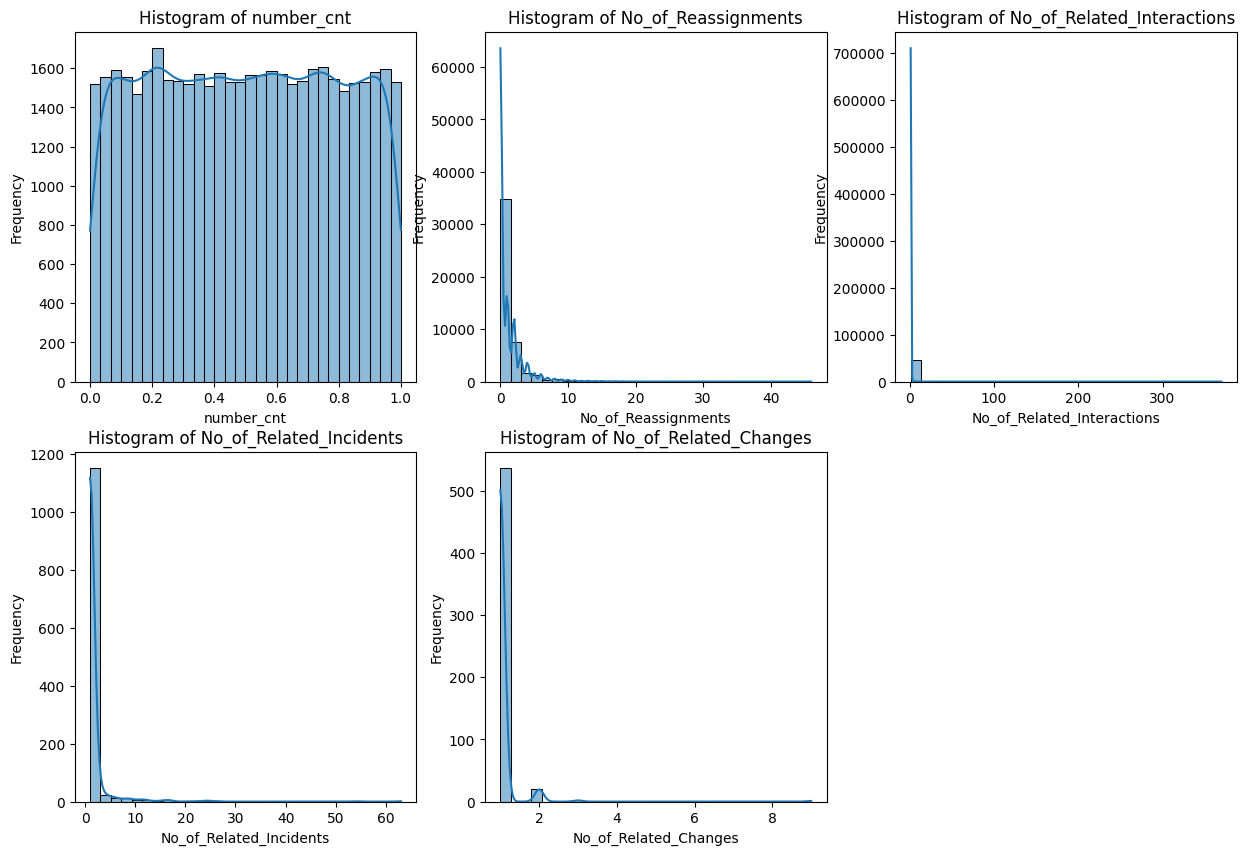

In [16]:
plt.figure(figsize=(15, 10))
plotnumber = 1
for column in df1.columns:
    if df1[column].dtype != 'object':
        plt.subplot(2, 3, plotnumber)
        sns.histplot(df1[column].dropna(), kde=True, bins=30)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plotnumber += 1
    if plotnumber > 6:
        break

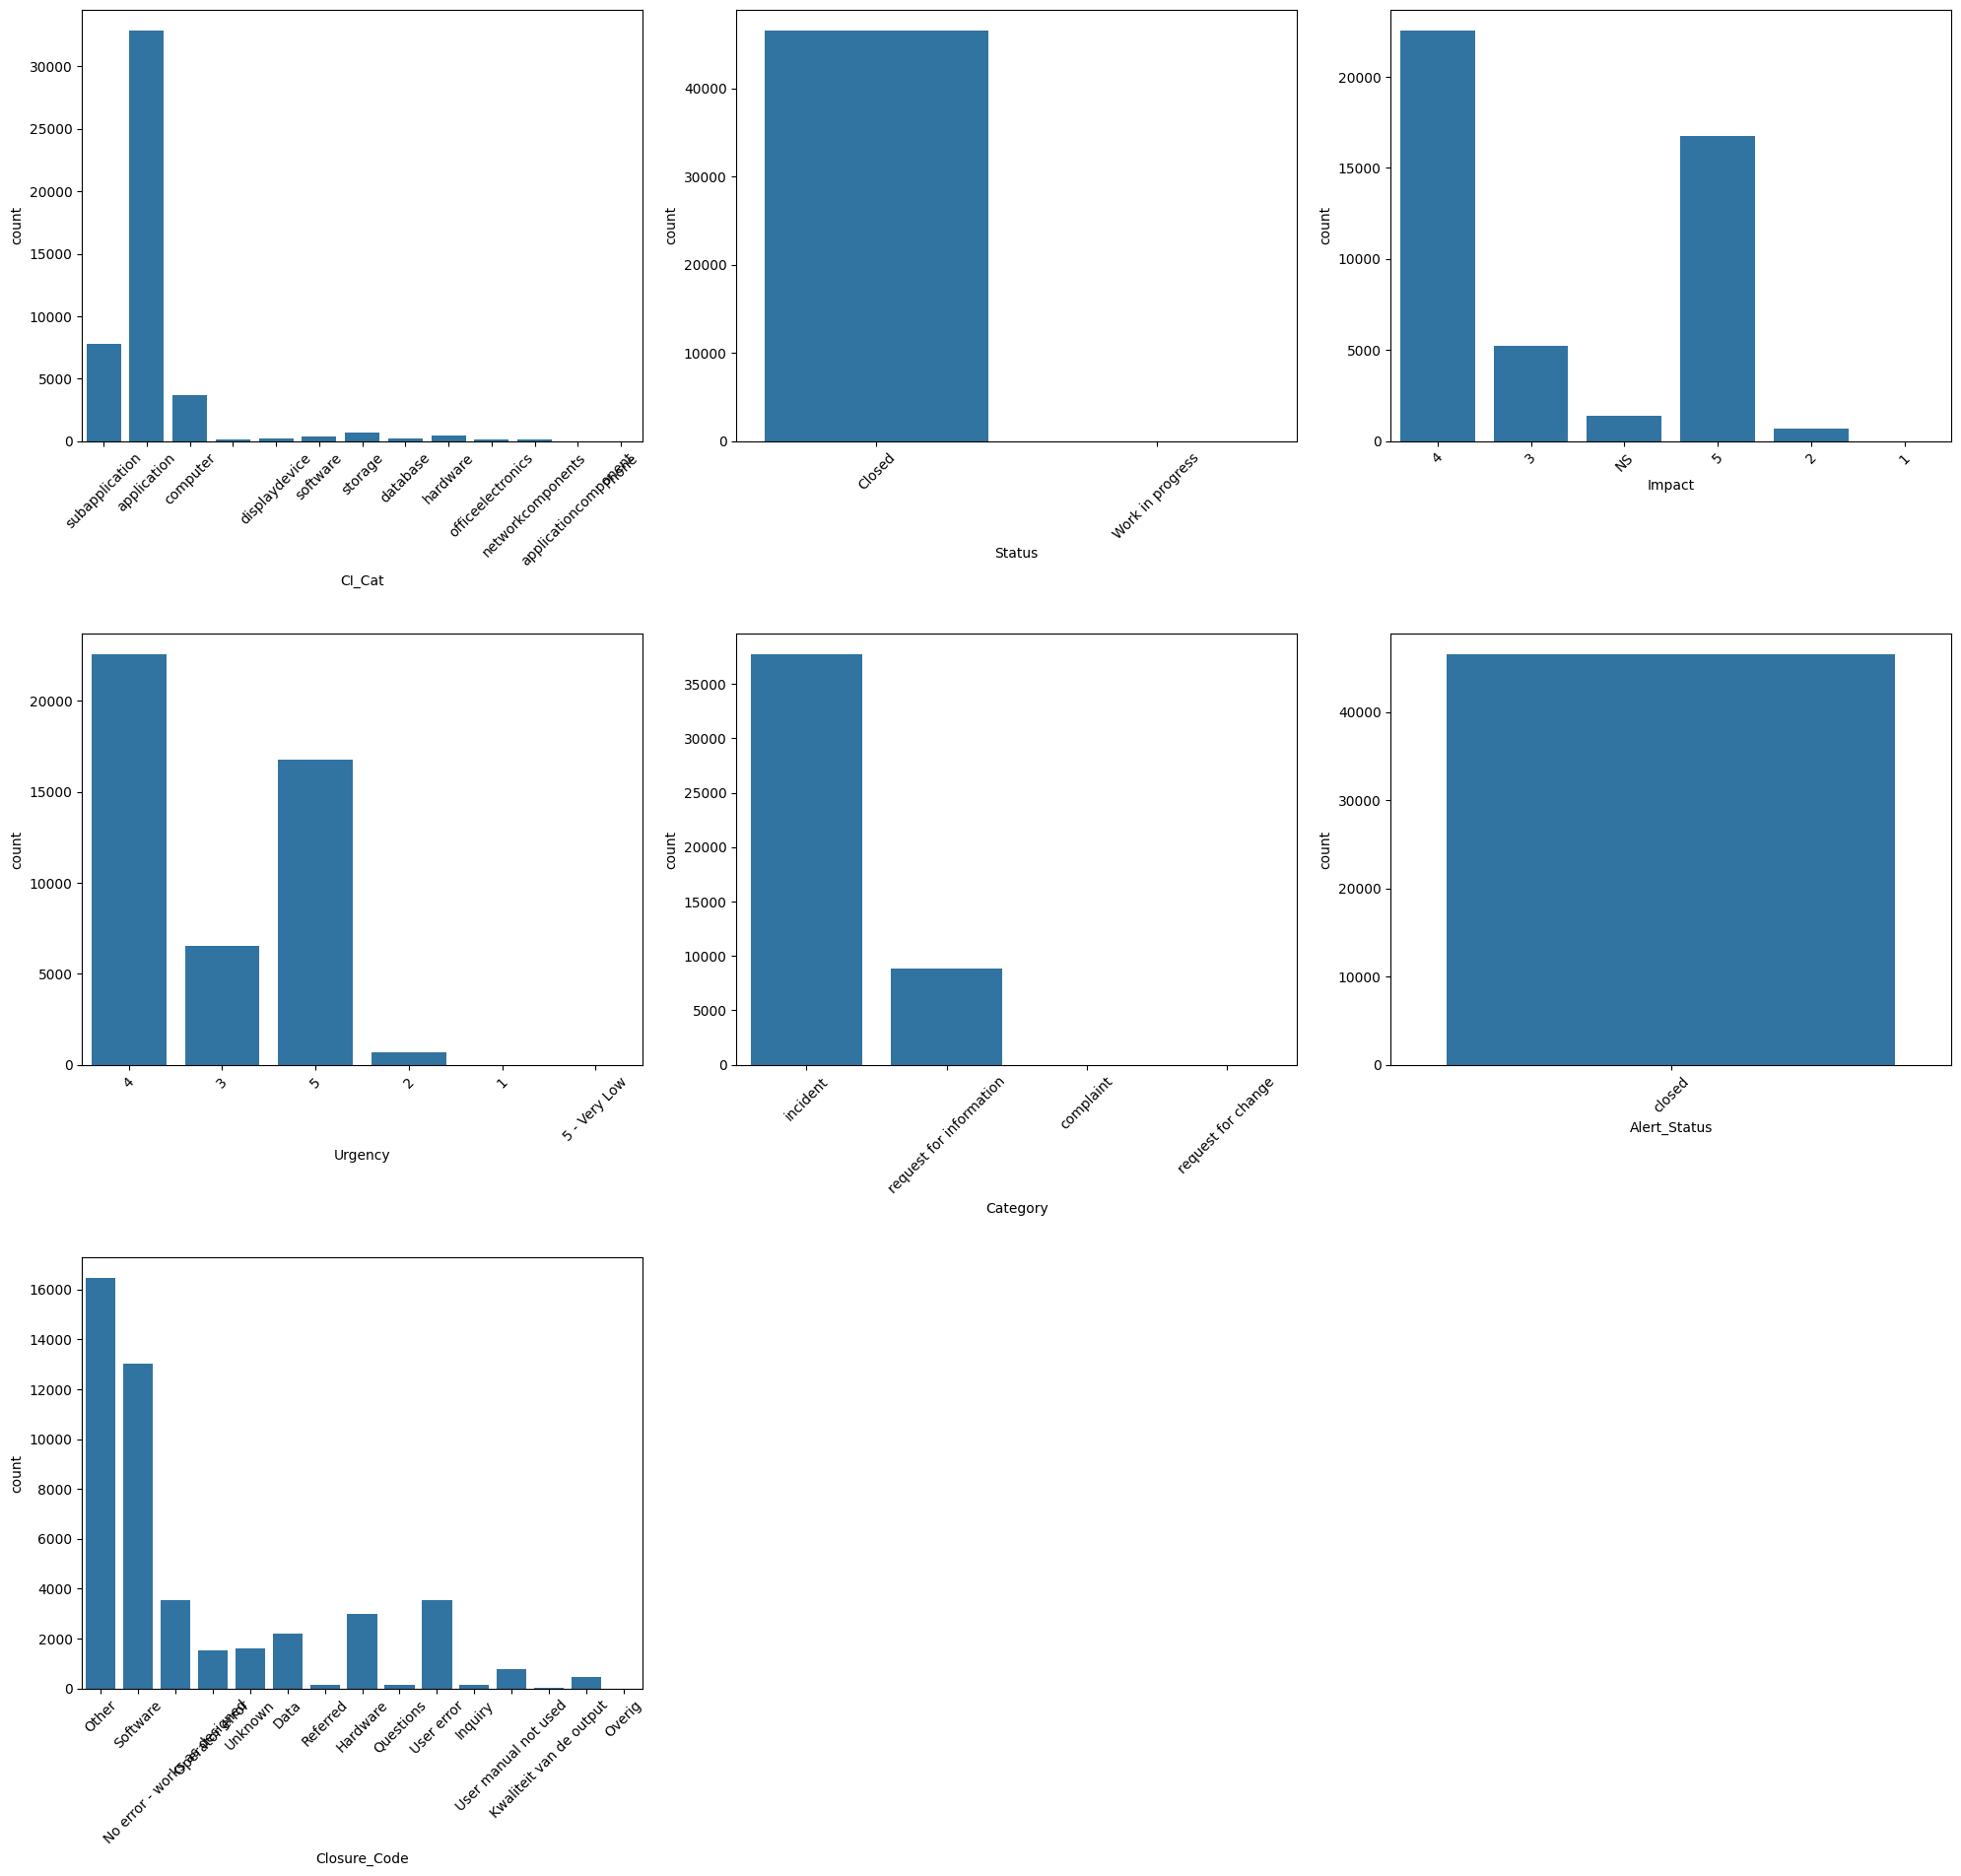

In [17]:
plt.figure(figsize=(20,30))
plotnumber = 1
for i in df2:
    if len(df2[i].unique()) < 20:
        plt.subplot(5,3,plotnumber)
        plt.xticks(rotation = 45)
        sns.countplot(x = df2[i])
        plotnumber += 1

plt.tight_layout()

# Bivariate Analysis

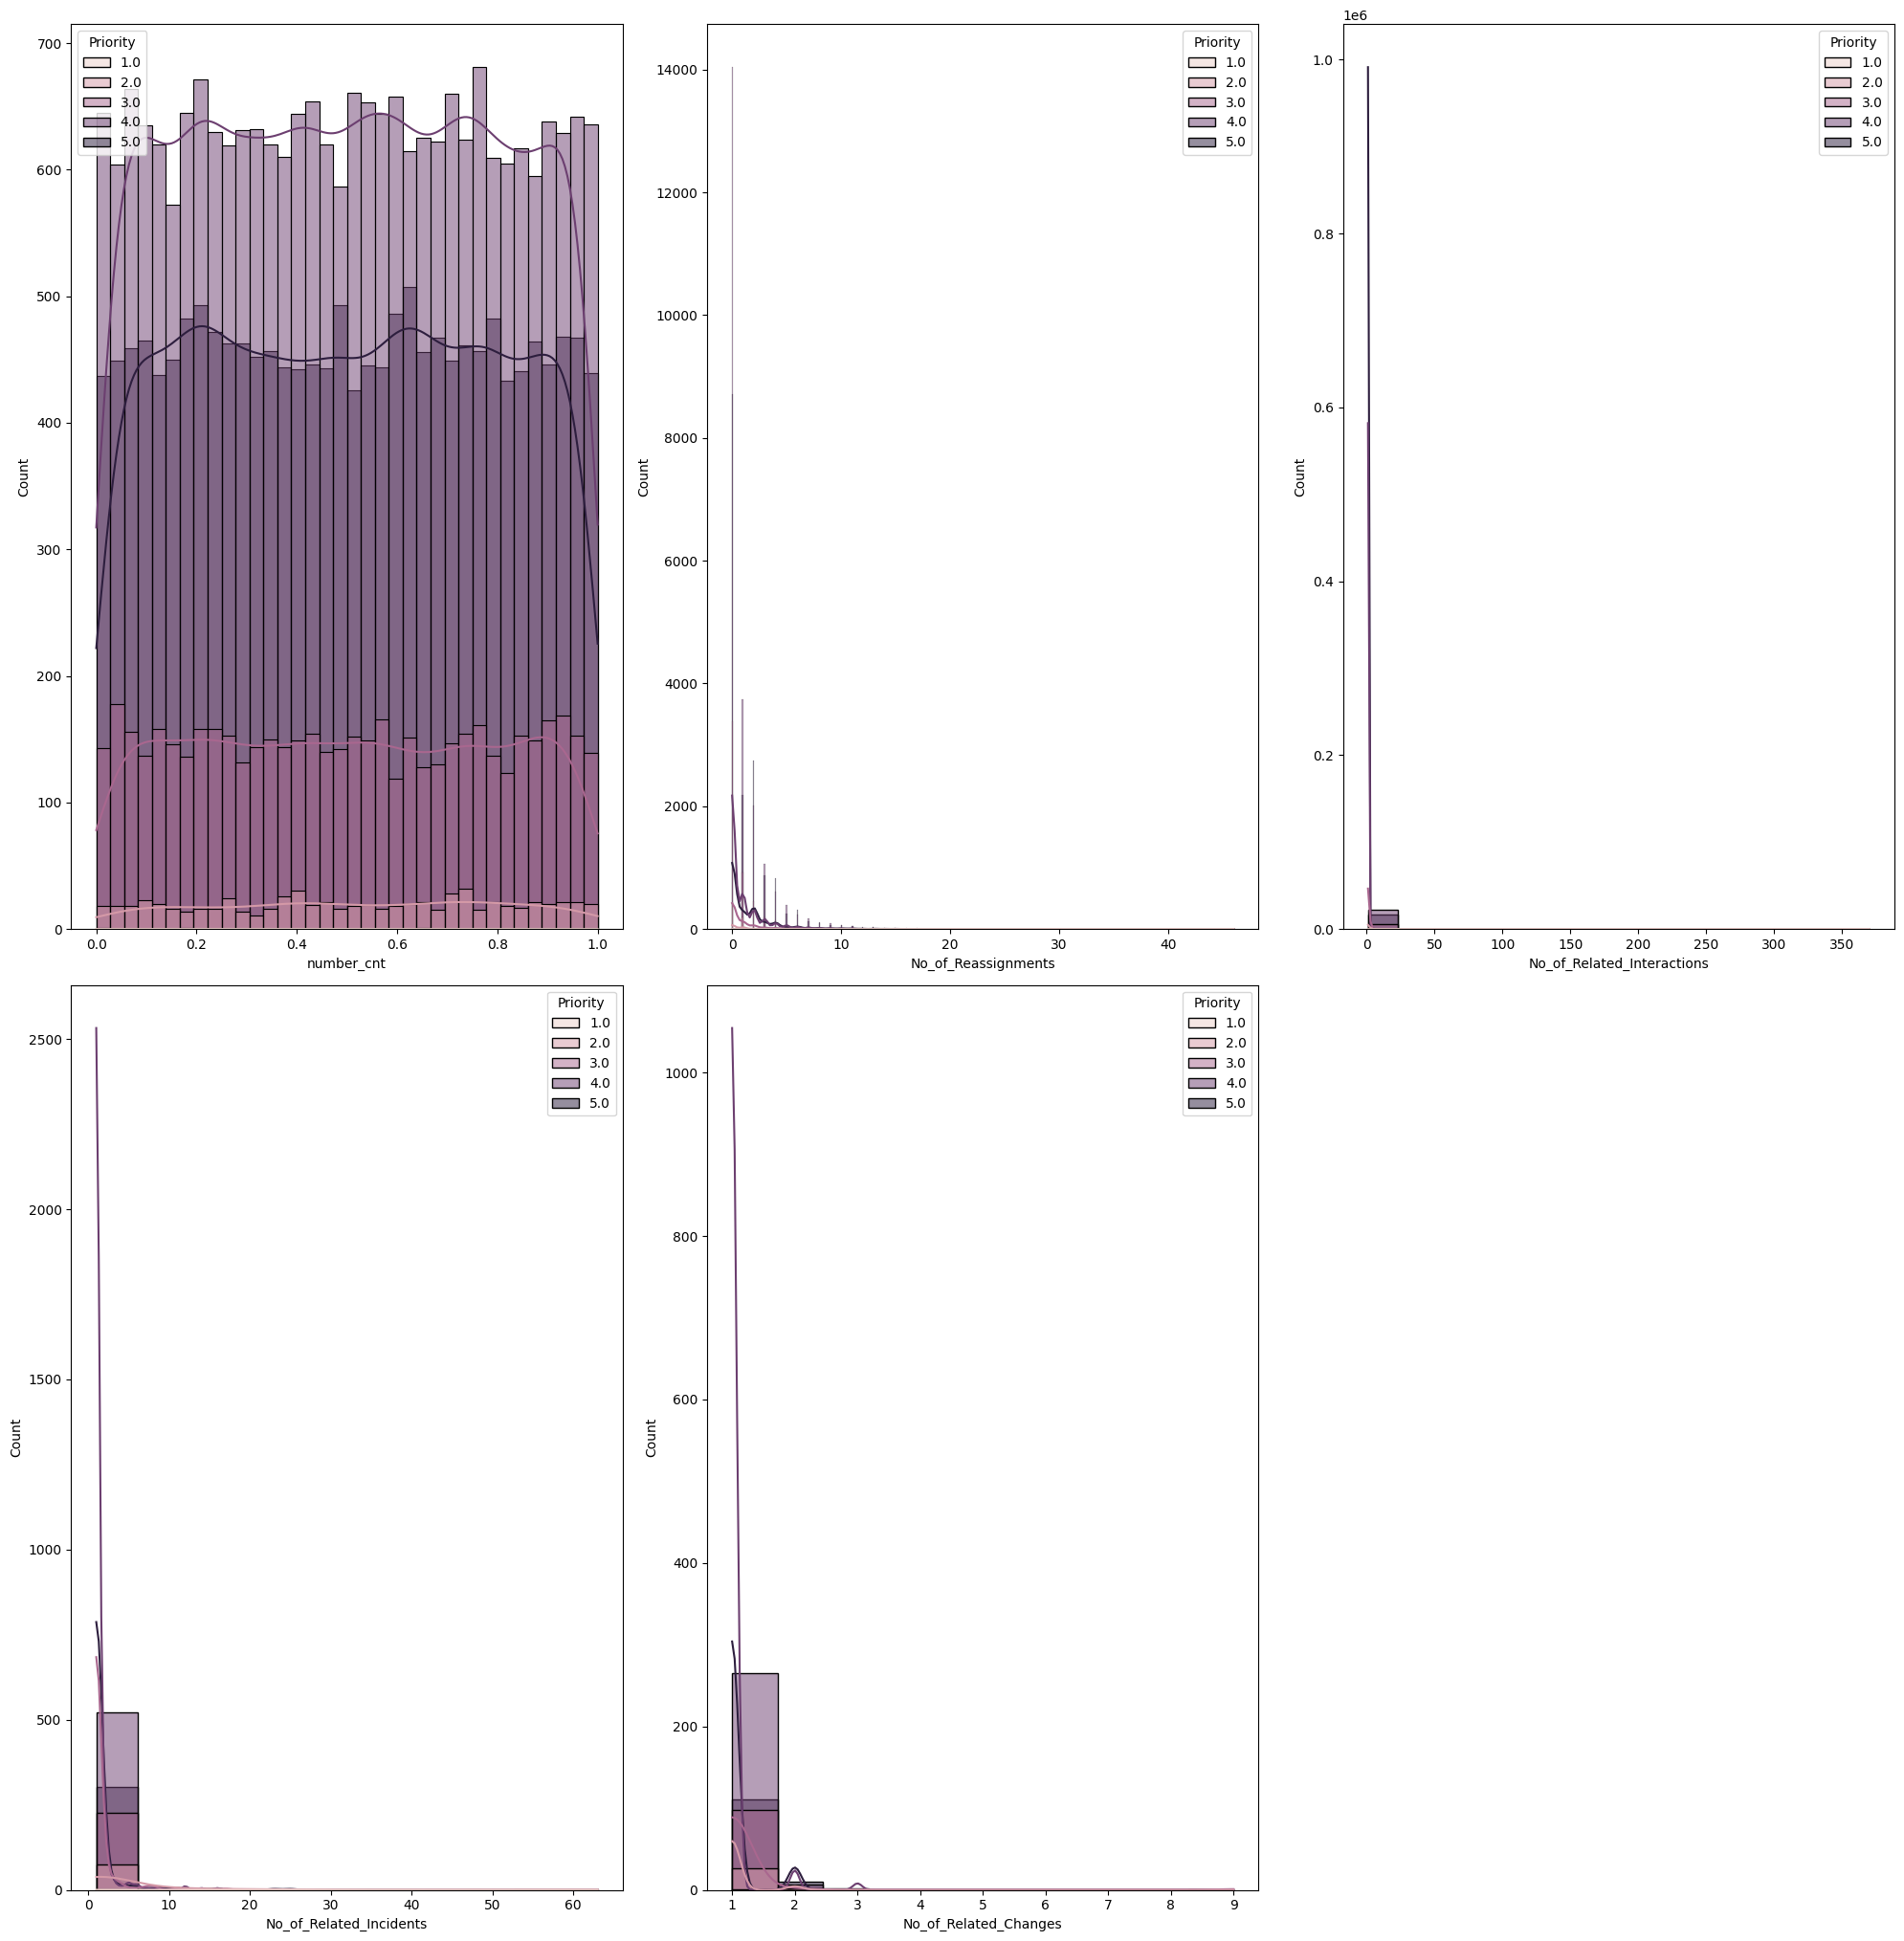

In [18]:
plt.figure(figsize =(20,30))
plotnumber = 1
for i in df1:
    plt.subplot(3,3,plotnumber)
    sns.histplot(x = df1[i],kde=True,hue= df.Priority)
    plotnumber += 1
plt.tight_layout()


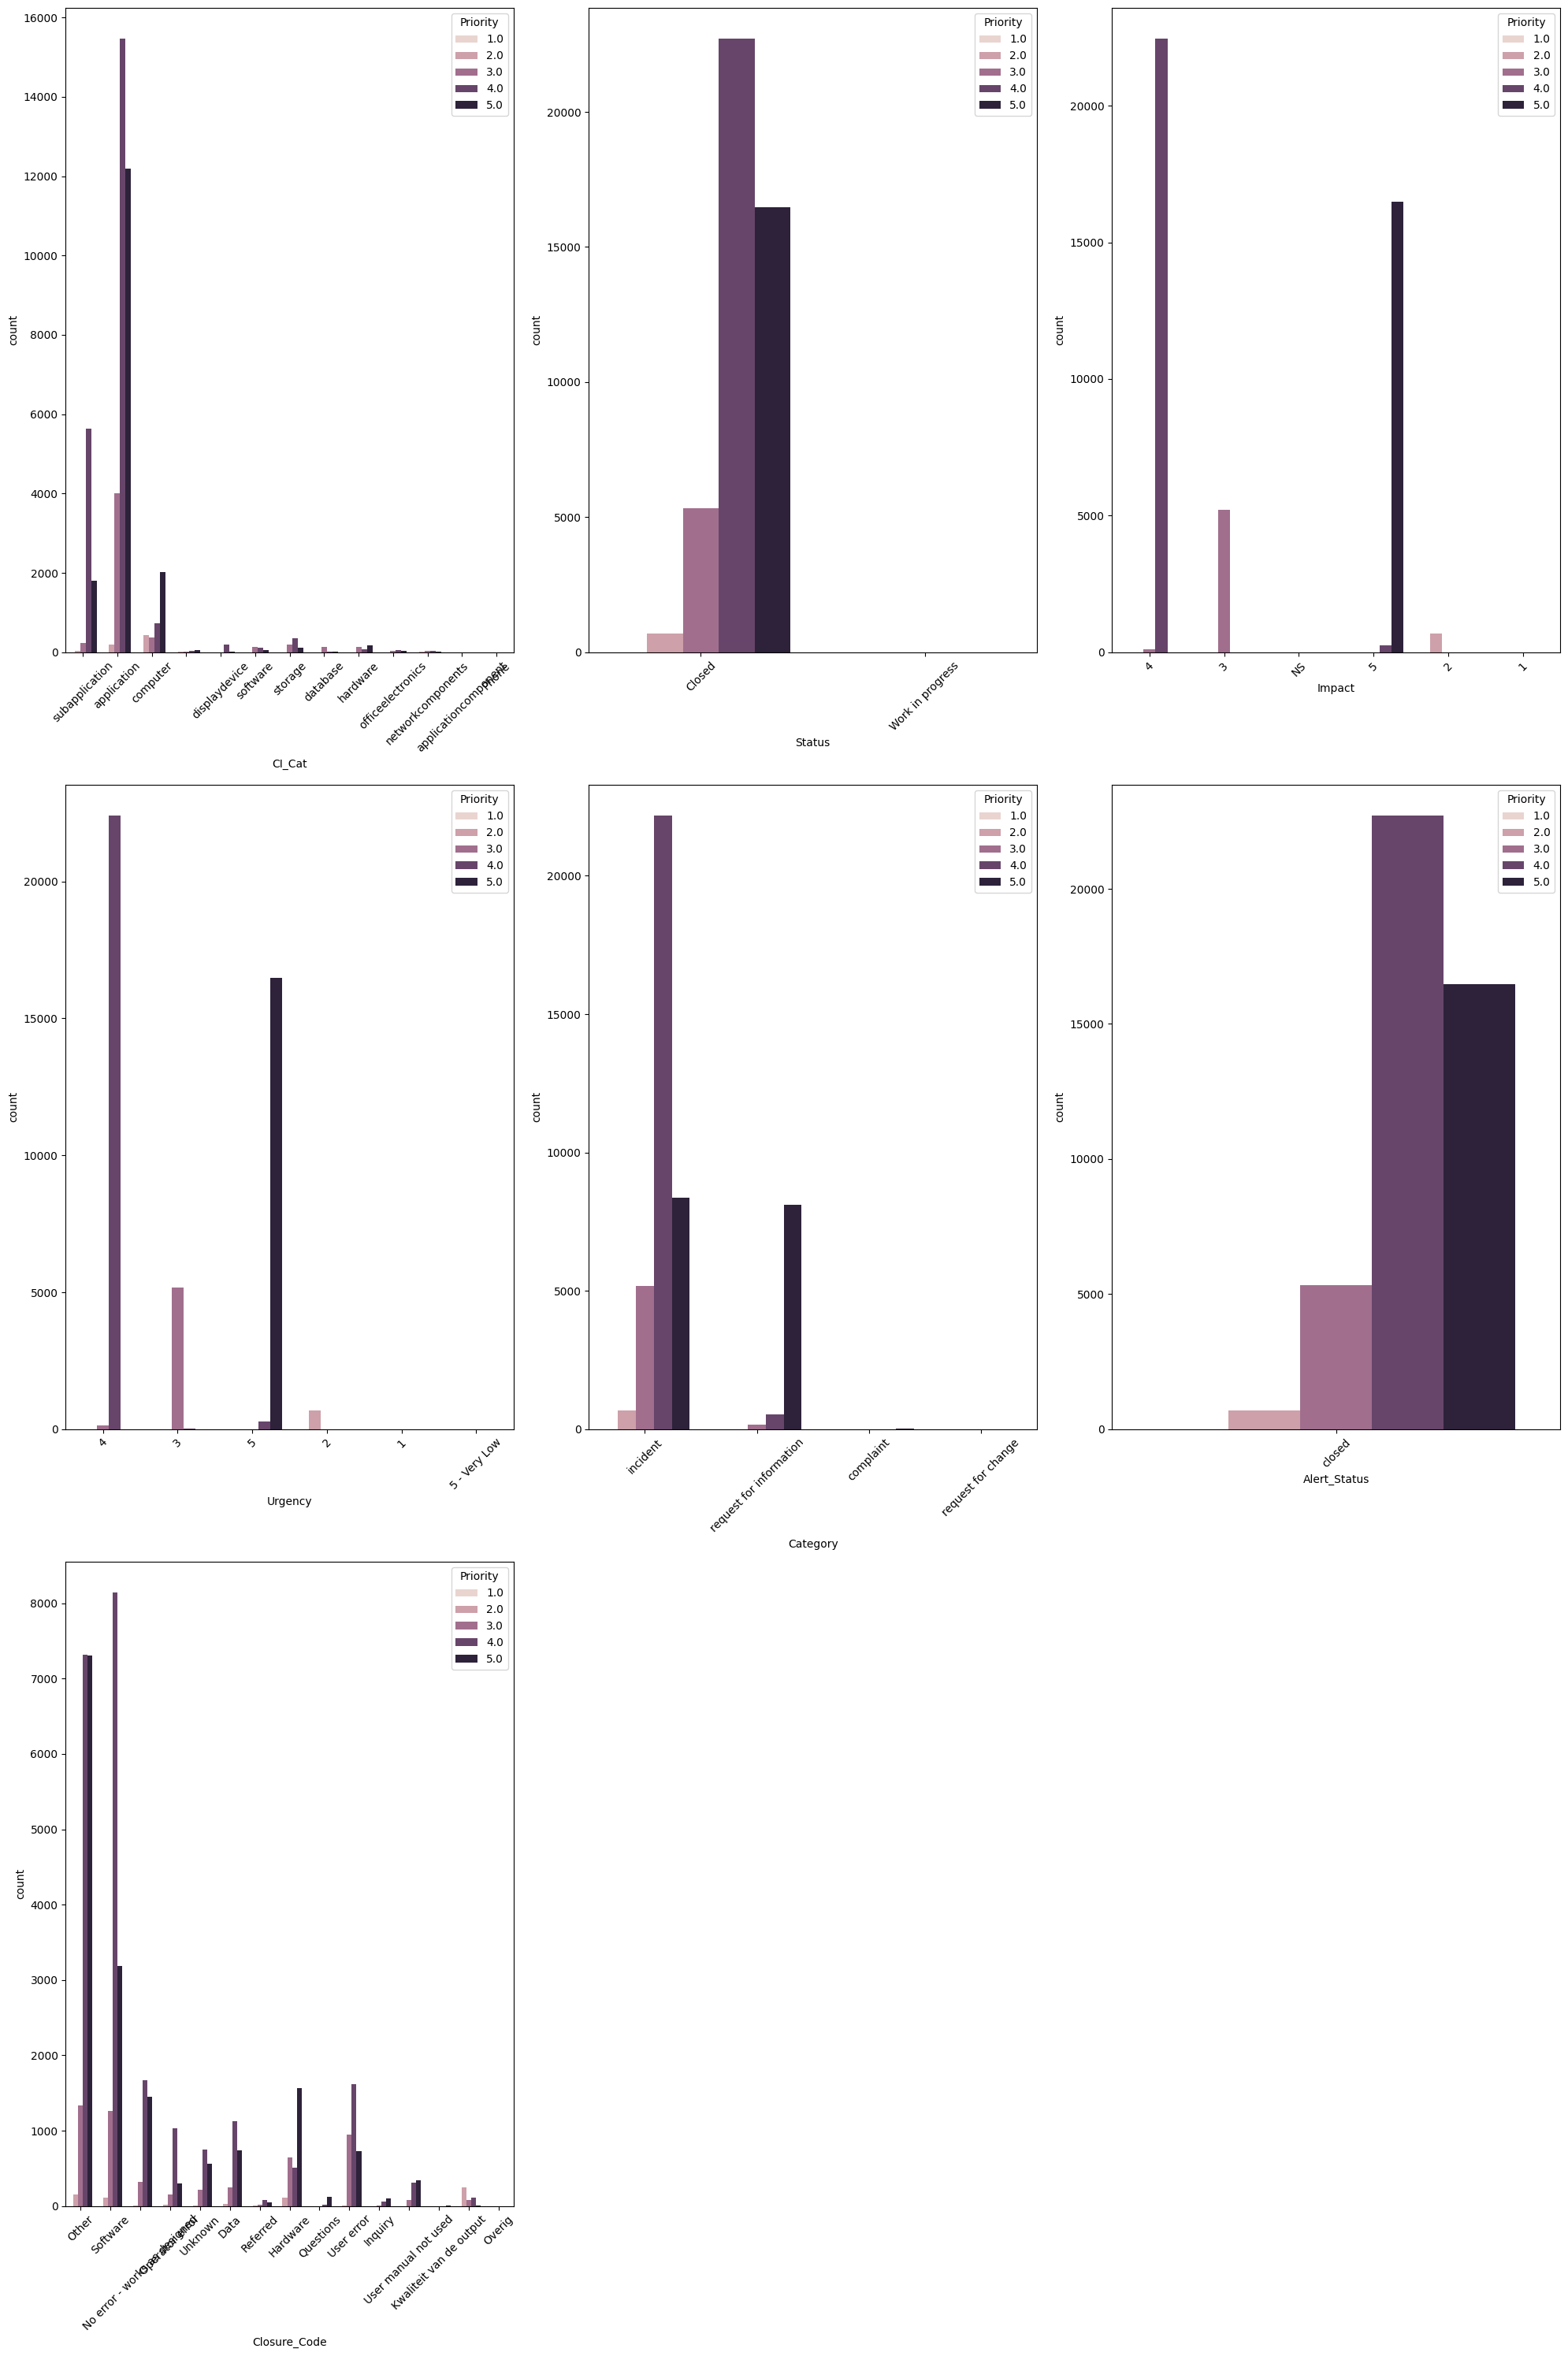

In [19]:
plt.figure(figsize =(20,30))
plotnumber = 1
for i in df2:
    if len(df2[i].unique()) < 20:
        plt.subplot(3,3,plotnumber)
        plt.xticks(rotation = 45)
        sns.countplot(x = df2[i],hue= df.Priority)
        plotnumber += 1
plt.tight_layout()

# EDA

In [20]:
df.isnull().sum()

,0
CI_Cat,0
CI_Subcat,0
WBS,0
Status,0
Impact,0
Urgency,0
Priority,1380
number_cnt,0
Category,0
Alert_Status,0


In [21]:
df.drop(columns=["Reopen_Time","No_of_Related_Incidents","No_of_Related_Changes","Related_Change"],inplace=True)

In [22]:
df['CI_Cat'].fillna('application', inplace=True)
df['CI_Subcat'].fillna('Server Based Application', inplace=True)
df['Priority'].fillna(df['Priority'].mode()[0], inplace=True)
df['Closure_Code'].fillna('Other', inplace=True)
df['No_of_Related_Interactions'].fillna(df['No_of_Related_Interactions'].mean(), inplace=True)
df['No_of_Reassignments'].fillna(df['No_of_Reassignments'].mean(), inplace=True)


In [23]:
df['Handle_Time_hrs'] = pd.to_numeric(df['Handle_Time_hrs'], errors='coerce')
df['Handle_Time_hrs'].fillna(df['Handle_Time_hrs'].mean(), inplace=True)

In [24]:
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'])
df['Resolved_Time'].fillna(df['Resolved_Time'].median(), inplace=True)

<Axes: >

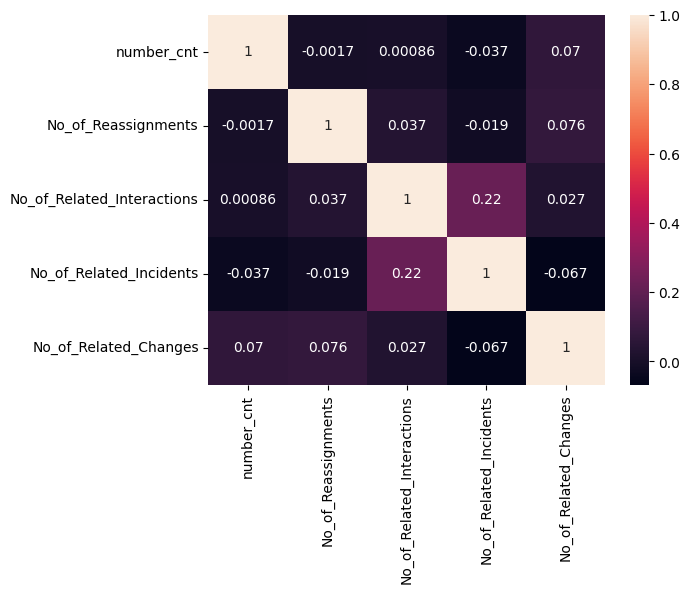

In [25]:
sns.heatmap(df1.corr(),annot= True)

# Feature Engineering

In [26]:
df1 = df[['Impact','Urgency', 'No_of_Reassignments', 'Priority']]
df1['High_Priority'] = df1['Priority'].apply(lambda x: 1 if x <= 2 else 0)
df1.drop('Priority', axis=1, inplace=True)

In [27]:
df1.head()

,Impact,Urgency,No_of_Reassignments,High_Priority
0,4,4,26.0,0
1,3,3,33.0,0
2,NS,3,3.0,0
3,4,4,13.0,0
4,4,4,2.0,0


In [28]:
df1.loc[df1.Impact == "NS", "Impact"] = "4"


In [29]:
df1.loc[df1.Urgency == '5 - Very Low', 'Urgency'] = 5

In [30]:
df1['Impact'] = df1['Impact'].astype(int)
df1['Urgency'] = df1['Urgency'].astype(int)
df1['No_of_Reassignments'] = df1['No_of_Reassignments'].astype(int)

# Creating a model

In [31]:
X =df1[["Impact","Urgency","No_of_Reassignments"]]
X

,Impact,Urgency,No_of_Reassignments
0,4,4,26
1,3,3,33
2,4,3,3
3,4,4,13
4,4,4,2
...,...,...,...
46601,4,4,0
46602,4,4,0
46603,5,5,0
46604,4,4,0


In [32]:
df.Impact.value_counts()

,count
Impact,
4,22556
5,16741
3,5234
NS,1380
2,692
1,3


In [33]:
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')  # Convert to numeric, setting non-numeric values as NaN
df['Impact'].fillna(df['Impact'].median(), inplace=True)  # Replace NaN with median

In [34]:
y = df1.High_Priority
y

,High_Priority
0,0
1,0
2,0
3,0
4,0
...,...
46601,0
46602,0
46603,0
46604,0


# Splitting the Model into train-test


In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state=42)

In [36]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test,y_pred))

Logistic Regression
Accuracy: 0.9998927268826432
F1 Score: 0.999892541605732
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9179
           1       1.00      0.99      1.00       143

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322



# Balancing the classes

In [37]:
sm = SMOTE()

In [38]:
x_sm,y_sm = sm.fit_resample(X_train,y_train)

In [39]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_sm))

Counter({0: 36727, 1: 557})
Counter({0: 36727, 1: 36727})


In [40]:
model = LogisticRegression()
model.fit(x_sm, y_sm)
y_pred = model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test,y_pred))

Logistic Regression
Accuracy: 1.0
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9179
           1       1.00      1.00      1.00       143

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322



In [41]:
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("SVC")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test,y_pred))

SVC
Accuracy: 0.9997854537652864
F1 Score: 0.9997847100063227
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9179
           1       1.00      0.99      0.99       143

    accuracy                           1.00      9322
   macro avg       1.00      0.99      1.00      9322
weighted avg       1.00      1.00      1.00      9322



# balancing the class

In [42]:
sv1 = SVC()
sv1.fit(x_sm,y_sm)
y_pred1 = sv1.predict(X_test)
acc_score = accuracy_score(y_test,y_pred1)
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9179
           1       1.00      1.00      1.00       143

    accuracy                           1.00      9322
   macro avg       1.00      1.00      1.00      9322
weighted avg       1.00      1.00      1.00      9322



In [43]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Decision Tree
Accuracy: 1.0
F1 Score: 1.0


In [44]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Random Forest
Accuracy: 1.0
F1 Score: 1.0


In [45]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Gradient Boosting
Accuracy: 1.0
F1 Score: 1.0


# Task2: Forecast the incident volume in different fields , quarterly and annual.

In [46]:
df['Open_Time'] = pd.to_datetime(df['Open_Time'], errors='coerce')

In [47]:
df_monthly = df.resample('M', on='Open_Time').size().reset_index(name='Incident_Volume')

# EDA

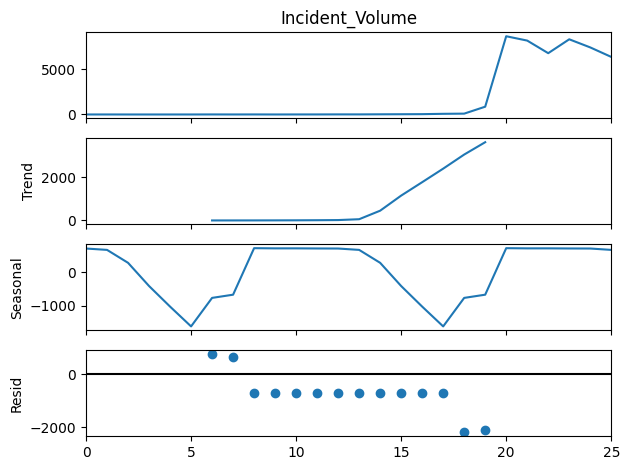

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df_monthly['Incident_Volume'], model='additive', period=12)
result.plot()
plt.show()

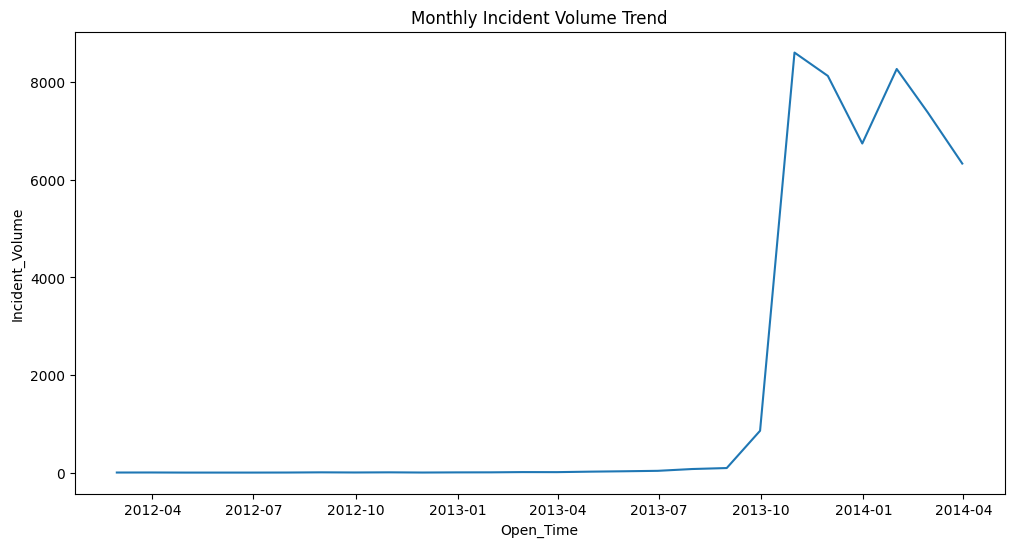

In [49]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Open_Time', y='Incident_Volume', data=df_monthly)
plt.title('Monthly Incident Volume Trend')
plt.show()

# ADF Test

In [50]:
result = adfuller(df_monthly['Incident_Volume'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 4.208344316554429
p-value: 1.0


In [51]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is not stationary.")

The time series is not stationary.


In [52]:
df_monthly['Diff_Volume'] = df_monthly['Incident_Volume'].diff().dropna()

# Building & training the ARIMA Model

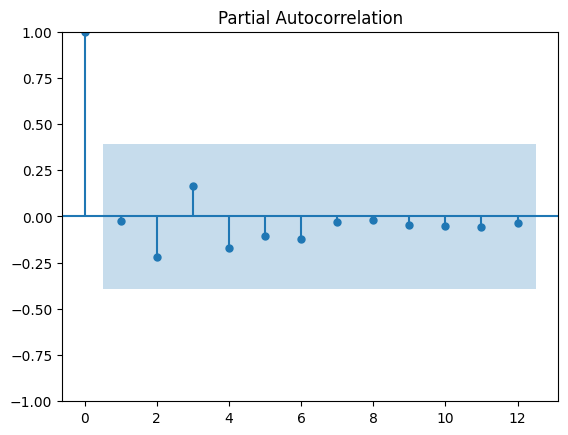

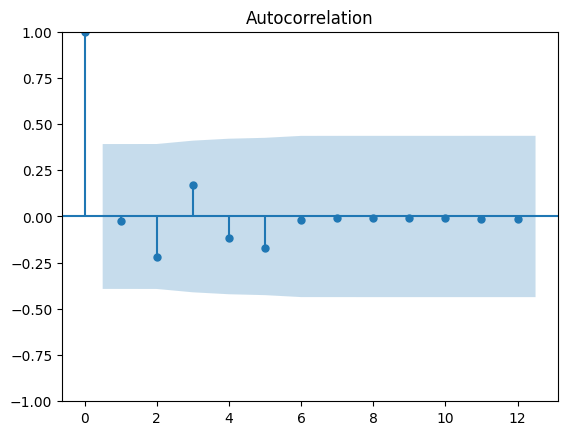

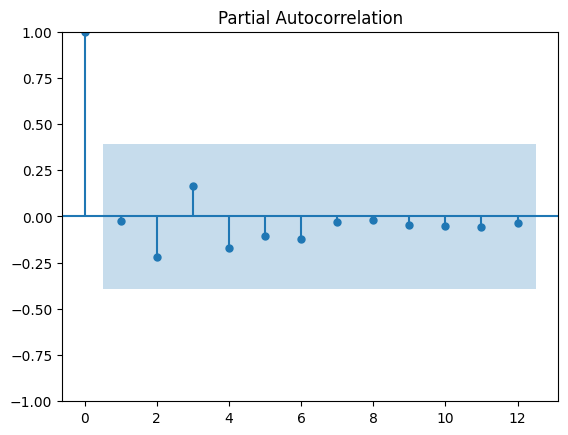

In [53]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_monthly['Incident_Volume'].diff().dropna())
plot_pacf(df_monthly['Incident_Volume'].diff().dropna())

In [54]:
# from pmdarima import auto_arima
# model = auto_arima(df_monthly['Incident_Volume'], seasonal=False, trace=True)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [55]:
model = ARIMA(df_monthly['Incident_Volume'], order=(1, 1, 1))
model_fit = model.fit()

In [56]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        Incident_Volume   No. Observations:                   26
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -219.963
Date:                Tue, 08 Jul 2025   AIC                            445.927
Time:                        12:24:55   BIC                            449.583
Sample:                             0   HQIC                           446.941
                                 - 26                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6828      0.886     -0.771      0.441      -2.419       1.054
ma.L1          0.8363      0.816      1.025      0.306      -0.763       2.436
sigma2      2.559e+06   2.54e+05     10.084      0.0

# Forecasting the volume

In [57]:
forecast = model_fit.forecast(steps=4)

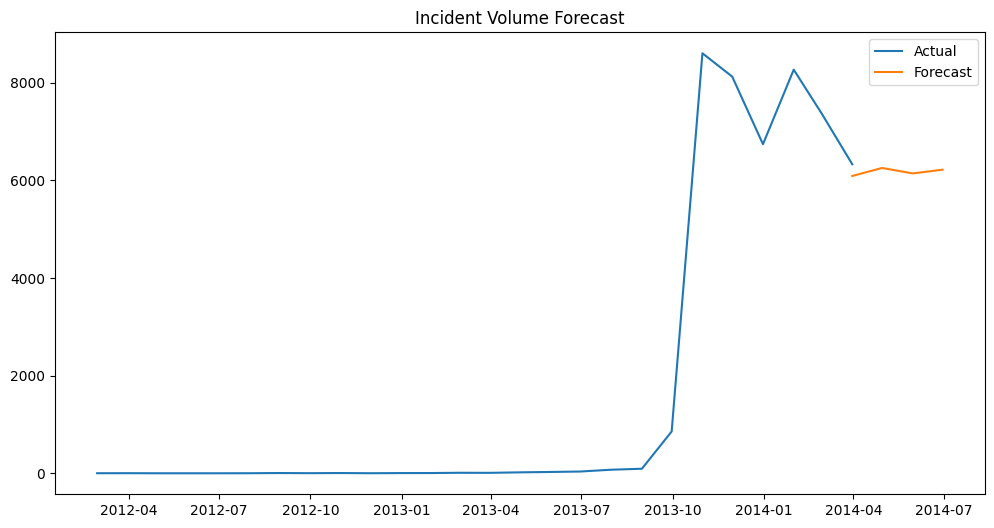

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Open_Time'], df_monthly['Incident_Volume'], label='Actual')
plt.plot(pd.date_range(start=df_monthly['Open_Time'].max(), periods=4, freq='M'), forecast, label='Forecast')
plt.title('Incident Volume Forecast')
plt.legend()
plt.show()

In [59]:
forecast = model_fit.forecast(steps=12)

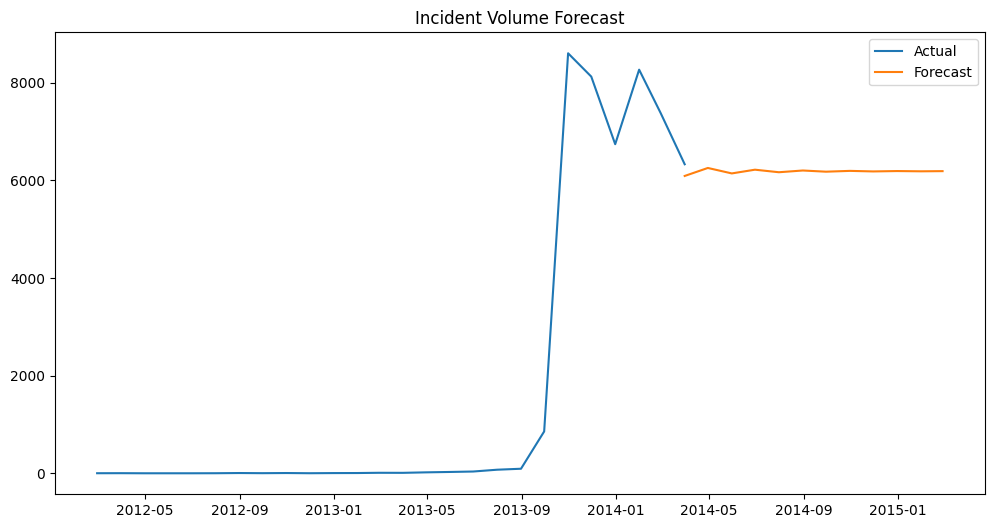

In [60]:
plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Open_Time'], df_monthly['Incident_Volume'], label='Actual')
plt.plot(pd.date_range(start=df_monthly['Open_Time'].max(), periods=12, freq='M'), forecast, label='Forecast')
plt.title('Incident Volume Forecast')
plt.legend()
plt.show()

# Evaluating the model

In [61]:
train_size = int(len(df_monthly) * 0.8)
train, test = df_monthly['Incident_Volume'][:train_size], df_monthly['Incident_Volume'][train_size:]

In [62]:
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

In [63]:
forecast = model_fit.forecast(steps=len(test))

In [64]:
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 6211.971342523647


In [65]:
from prophet import Prophet
df_prophet = df_monthly.rename(columns={'Open_Time': 'ds', 'Incident_Volume': 'y'})

In [66]:
model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpedmjb94c/a_jxzr9j.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpedmjb94c/27l8l_fu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=58548', 'data', 'file=/tmp/tmpedmjb94c/a_jxzr9j.json', 'init=/tmp/tmpedmjb94c/27l8l_fu.json', 'output', 'file=/tmp/tmpedmjb94c/prophet_modeldl5ufq5q/prophet_model-20250708122539.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
12:25:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:25:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:

In [67]:
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

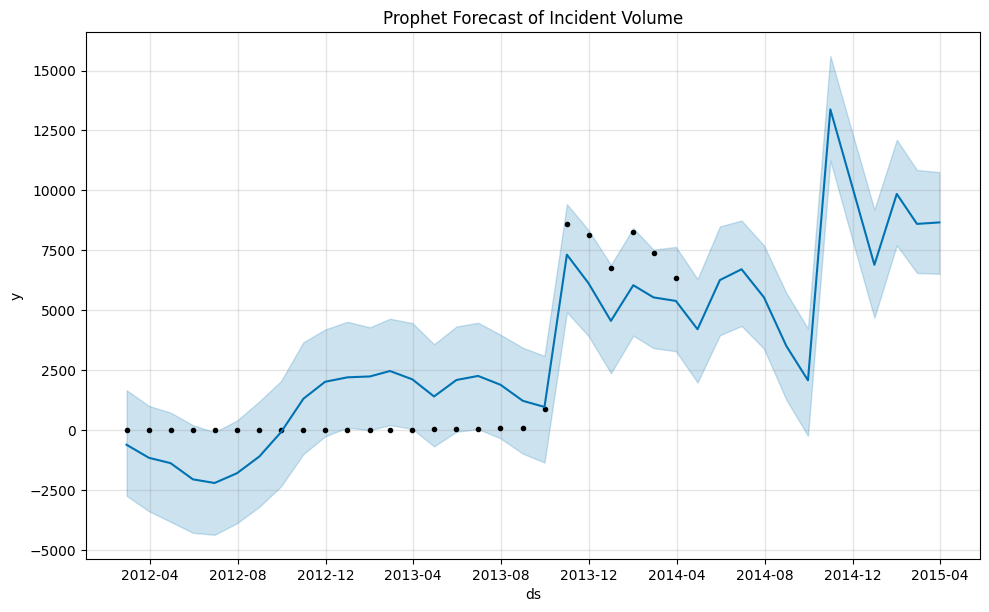

In [68]:
fig = model.plot(forecast)
plt.title('Prophet Forecast of Incident Volume')
plt.show()

# Task3: Autotagging of the tickets based on priorities & departments

In [69]:
df1 = df[["Impact","Urgency","CI_Cat","CI_Subcat","Status","Category","Priority"]]

# Encoding of the categorical columns

In [70]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df1['Category_Encoded'] = label_encoder.fit_transform(df1['CI_Cat'])
df1['Subcategory_Encoded'] = label_encoder.fit_transform(df1['CI_Subcat'])
df1['Status_Encoded'] = label_encoder.fit_transform(df1['Status'])
df1['Category_Encoded'] = label_encoder.fit_transform(df1['Category'])


# Splitting the data

In [71]:
X = df1[['Impact', 'Urgency','Category_Encoded', 'Subcategory_Encoded',]]
X

,Impact,Urgency,Category_Encoded,Subcategory_Encoded
0,4.0,4,1,58
1,3.0,3,1,58
2,4.0,3,3,11
3,4.0,4,1,58
4,4.0,4,1,58
...,...,...,...,...
46601,4.0,4,1,46
46602,4.0,4,1,46
46603,5.0,5,1,22
46604,4.0,4,1,58


In [72]:
X.loc[df.Urgency == '5 - Very Low', 'Urgency'] = 5
X['Urgency'] = X['Urgency'].astype(int)
X['Impact'] = pd.to_numeric(X['Impact'], errors='coerce')
X['Impact'] = X['Impact'].astype(int)

In [73]:
y = df.Priority
y

,Priority
0,4.0
1,3.0
2,4.0
3,4.0
4,4.0
...,...
46601,4.0
46602,4.0
46603,5.0
46604,4.0


In [74]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test,y_pred))


Decision Tree
Accuracy: 0.9967818064792963
F1 Score: 0.9967680759725022
              precision    recall  f1-score   support

         2.0       1.00      1.00      1.00       143
         3.0       1.00      0.98      0.99      1100
         4.0       0.99      1.00      1.00      4795
         5.0       1.00      1.00      1.00      3284

    accuracy                           1.00      9322
   macro avg       1.00      0.99      1.00      9322
weighted avg       1.00      1.00      1.00      9322



In [76]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test,y_pred))

Random Forest
Accuracy: 0.9967818064792963
F1 Score: 0.9967669131709975
              precision    recall  f1-score   support

         2.0       1.00      1.00      1.00       143
         3.0       1.00      0.97      0.99      1100
         4.0       0.99      1.00      1.00      4795
         5.0       1.00      1.00      1.00      3284

    accuracy                           1.00      9322
   macro avg       1.00      0.99      1.00      9322
weighted avg       1.00      1.00      1.00      9322



# TASK3 ii) - Autotagging of tickets with right departments

In [77]:
df1.drop(columns = "Status",inplace = True )

In [78]:
df1.loc[df1.Category == "incident","Category"]=0
df1.loc[df1.Category == "request for information","Category"]=1
df1.loc[df1.Category == "complaint","Category"]=2
df1.loc[df1.Category == "request for change","Category"]=3

In [79]:
x= df1[['Impact', 'Urgency', 'Category_Encoded', 'Subcategory_Encoded', 'Priority']]
y = df1[["Category"]]

In [80]:
y = y.astype(int)

In [81]:
x['Impact'] = pd.to_numeric(x['Impact'], errors='coerce')
x['Impact'] = x['Impact'].astype(int)
x.loc[x.Urgency == '5 - Very Low', 'Urgency'] = 5
x['Urgency'] = x['Urgency'].astype(int)
x['Priority'] = x['Priority'].astype(int)


In [82]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [83]:
model = LogisticRegression(multi_class='ovr')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred,average='weighted'))


Logistic Regression
Accuracy: 0.9997854384208268
F1 Score: 0.9996781706367307


In [84]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Decision Tree
Accuracy: 0.999928479473609
F1 Score: 0.9998927207923759


In [85]:
model = GradientBoostingClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Gradient Boosting
Accuracy: 0.999928479473609
F1 Score: 0.9998927207923759


In [86]:
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


XGBoost
Accuracy: 0.999928479473609
F1 Score: 0.9998927207923759


 # Task4: Predicting RFC (Request for Change) Failures and Misconfiguration in ITSM Assets

### The No_of_Related_Incidents column presents a major challenge due to the high volume of missing (null) values. This significantly limits our ability to proceed with Task 4, which involves analyzing incident relationships and patterns.

### A substantial portion of this data is either incomplete or entirely absent, making it difficult to establish meaningful links between incidents. As a result, any attempt to extract insights or detect failure patterns tied to related incidents would lack reliability and analytical depth.